## Assignment 6



In [19]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, clear_output, display, Math
import time
from math import erf
from scipy.special import erf

In [20]:
# --------------------------
# Constants and known values
# --------------------------
g = 9.81  # gravitational acceleration (m/s^2)
viscosity = 1e-6  # kinematic viscosity of water (m^

### Question 1
Consider laminar flow above a suddenly moved plate. Plot the approximate and exact velocity profiles
i.e plot u/u0 versus y/δ. Reproduce all of the exact and approximate results in Table 5.

In [21]:
# Symbolic variable
eta = sp.Symbol('eta', real=True)

In [22]:
# ---------------------------------------------------------
# Approximate solutions
# ---------------------------------------------------------

# Velocity profiles (from the table)
f1 = 1 - eta
f2 = (1 - eta)**2
f3 = 1 - sp.sin(sp.pi / 2 * eta)

# Derivatives
df1 = sp.diff(f1, eta)
df2 = sp.diff(f2, eta)
df3 = sp.diff(f3, eta)

# Integrands for Eq. 5.48
integ_f1 = eta * df1
integ_f2 = eta * df2
integ_f3 = eta * df3

# Boundary layer thickness
# Not dividing by np.sqrt(viscosity*time) since it cancels out in the ratios
# but if calculating on numbers it should be included
delta_1 = float(sp.sqrt(2 * df1.subs(eta, 0) / sp.integrate(integ_f1, (eta, 0, 1))))
delta_2 = float(sp.sqrt(2 * df2.subs(eta, 0) / sp.integrate(integ_f2, (eta, 0, 1))))
delta_3 = float(sp.sqrt(2 * df3.subs(eta, 0) / sp.integrate(integ_f3, (eta, 0, 1))))

# Displacement thickness (Eq. 5.49)
deltastar_1 = float(delta_1 * sp.integrate(f1, (eta, 0, 1)))
deltastar_2 = float(delta_2 * sp.integrate(f2, (eta, 0, 1)))
deltastar_3 = float(delta_3 * sp.integrate(f3, (eta, 0, 1)))

# Bed shear stress (Eq. 5.45)
# Again not including the rho and viscosity 
bedshear_1 = float(df1.subs(eta, 0) / delta_1)
bedshear_2 = float(df2.subs(eta, 0) / delta_2)
bedshear_3 = float(df3.subs(eta, 0) / delta_3)

print("Approximate solution with First-order polynomial")
print(f"Boundary layer thickness= {delta_1:.3f}, Displacement thickness= {deltastar_1:.3f}, Bed shear stress= {bedshear_1:.3f}\n")

print("Approximate solution with Second-order polynomial")
print(f"Boundary layer thickness= {delta_2:.3f}, Displacement thickness= {deltastar_2:.3f}, Bed shear stress= {bedshear_2:.3f}\n")

print("Approximate solution with Sine function")
print(f"Boundary layer thickness= {delta_3:.3f}, Displacement thickness= {deltastar_3:.3f}, Bed shear stress= {bedshear_3:.3f}\n")

Approximate solution with First-order polynomial
Boundary layer thickness= 2.000, Displacement thickness= 1.000, Bed shear stress= -0.500

Approximate solution with Second-order polynomial
Boundary layer thickness= 3.464, Displacement thickness= 1.155, Bed shear stress= -0.577

Approximate solution with Sine function
Boundary layer thickness= 2.940, Displacement thickness= 1.068, Bed shear stress= -0.534



In [23]:
# ---------------------------------------------------------
# Exact solutions
# ---------------------------------------------------------

def delta_exact(U):
    func = lambda Y: U - (1 - erf(Y / 2))
    return fsolve(func, 0.5)[0]

# For U = 0.01
U1 = 0.01
delta_exa_1 = delta_exact(U1)
f1_exa = lambda eta: 1 - erf(delta_exa_1 * eta / 2)
df1_exa = lambda eta: -(delta_exa_1 / np.sqrt(np.pi)) * np.exp(-(delta_exa_1 * eta / 2)**2)
deltastar_exa_1 = delta_exa_1 * float(sp.integrate(1 - sp.erf(delta_exa_1 * eta / 2), (eta, 0, 1)))
bedshear_exa_1 = float(df1_exa(0) / delta_exa_1)

# For U = 0.001
U2 = 0.001
delta_exa_2 = delta_exact(U2)
f2_exa = lambda eta: 1 - erf(delta_exa_2 * eta / 2)
df2_exa = lambda eta: -(delta_exa_2 / np.sqrt(np.pi)) * np.exp(-(delta_exa_2 * eta / 2)**2)
deltastar_exa_2 = delta_exa_2 * float(sp.integrate(1 - sp.erf(delta_exa_2 * eta / 2), (eta, 0, 1)))
bedshear_exa_2 = float(df2_exa(0) / delta_exa_2)

print("Exact solution with U=0.01")
print(f"Boundary layer thickness= {delta_exa_1:.3f}, Displacement thickness= {deltastar_exa_1:.3f}, Bed shear stress= {bedshear_exa_1:.3f}\n")

print("Exact solution with U=0.001")
print(f"Boundary layer thickness= {delta_exa_2:.3f}, Displacement thickness= {deltastar_exa_2:.3f}, Bed shear stress= {bedshear_exa_2:.3f}\n")


Exact solution with U=0.01
Boundary layer thickness= 3.643, Displacement thickness= 1.124, Bed shear stress= -0.564

Exact solution with U=0.001
Boundary layer thickness= 4.654, Displacement thickness= 1.128, Bed shear stress= -0.564



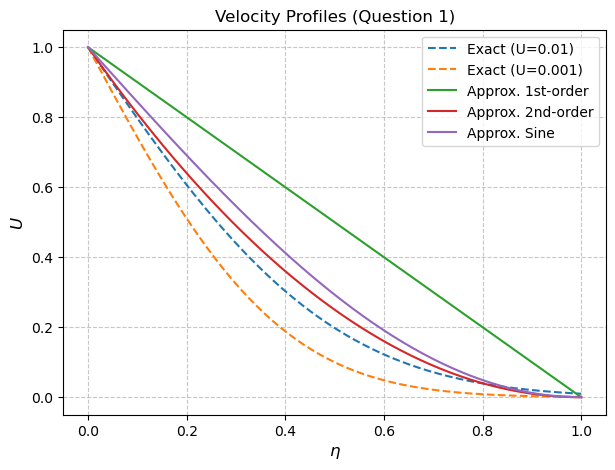

In [28]:
# -------------------------------------------------
# Plotting
# -------------------------------------------------
eta_vals = np.linspace(0, 1, 200)

plt.figure(figsize=(7, 5))
plt.plot(eta_vals, f1_exa(eta_vals), label='Exact (U=0.01)', linestyle='--')
plt.plot(eta_vals, f2_exa(eta_vals), label='Exact (U=0.001)', linestyle='--')
plt.plot(eta_vals, [1 - e for e in eta_vals], label='Approx. 1st-order')
plt.plot(eta_vals, [(1 - e)**2 for e in eta_vals], label='Approx. 2nd-order')
plt.plot(eta_vals, [1 - np.sin(np.pi/2 * e) for e in eta_vals], label='Approx. Sine')

plt.xlabel(r'$\eta$', fontsize=12)
plt.ylabel(r'$U$', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.title('Velocity Profiles (Question 1)')
plt.show()

#### Results
This graph is presenting velocity profiles across a boundary layer, plotted against the similarity variable eta. In other words, it shows how the dimensionless velocity U changes from the wall (eta = 0) to the edge of the boundary layer (eta = 1)

In the velocity profile graph, the largest velocity is always right at the wall, at eta = 0. 

### Question 2
Consider laminar boundary layer flow with an outer pressure gradient (e.g. as sketched in Figure 5.8).
Reproduce the results shown in Figure 5.9. Make sure you understand qualitatively why converging
(diverging) flow results in a favorable (adverse) pressure gradient
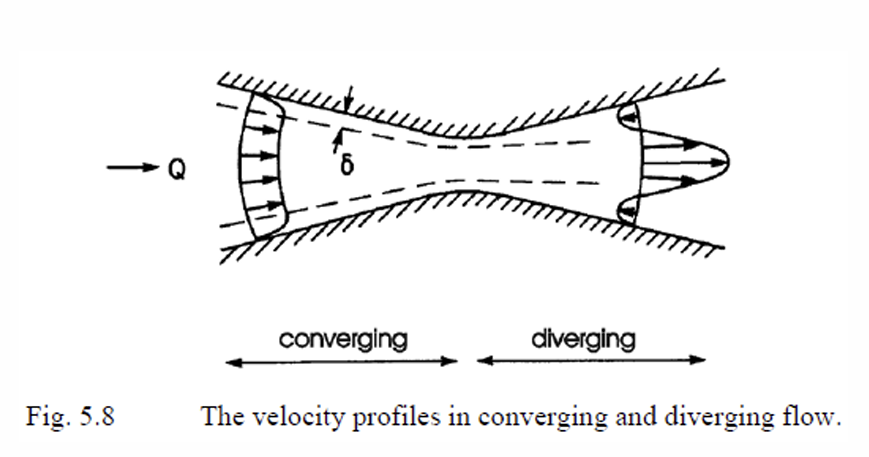

<>:21: SyntaxWarning: invalid escape sequence '\L'
<>:21: SyntaxWarning: invalid escape sequence '\L'
C:\Users\natal\AppData\Local\Temp\ipykernel_40944\3491726118.py:21: SyntaxWarning: invalid escape sequence '\L'
  plt.title('Velocity Profiles for Different $\Lambda$ (Question 2)')


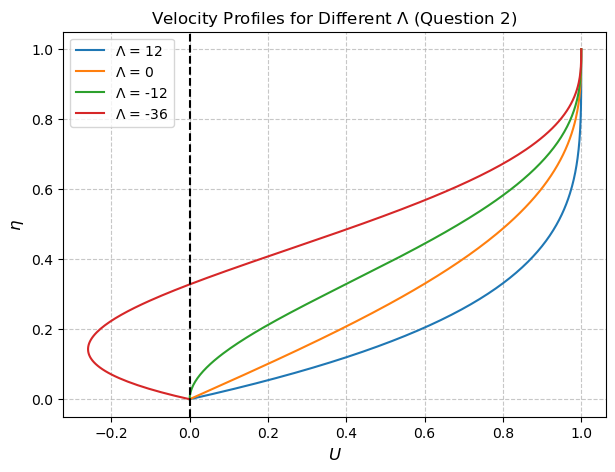

In [ ]:
# Initialize the equations
F = 2*eta - 2*eta**3 + eta**4                           # Eq. 5.68a (Shape function part)
G = (1/6)*(eta - 3*eta**2 + 3*eta**3 - eta**4)          # Eq. 5.68b (Shape function part)
U_2 = sp.lambdify((eta, lam), F + lam*G, 'numpy')       # Complete velocity profile function


# -------------------------------------------------
# Second plot
# -------------------------------------------------
eta_vals = np.linspace(0, 1, 200)

plt.figure(figsize=(7, 5))
for Λ in [12, 0, -12, -36]:
    plt.plot(U_2(eta_vals, Λ), eta_vals, label=fr'$\Lambda$ = {Λ}')
plt.axvline(0, color='k', linestyle='--')

plt.ylabel(r'$\eta$', fontsize=12)
plt.xlabel(r'$U$', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.title('Velocity Profiles for Different $\Lambda$ (Question 2)')
plt.show()

#### Results
This construction is a parametric approximation:
- F(eta) gives a base shape that satisfies boundary conditions.
- G(eta) is a correction function.
- Λ is a free parameter that adjusts the profile to match physical conditions (like pressure gradient effects).

Free parameters values:
- Λ=0: No pressure gradient
- Λ>0: Favorable pressure gradient
- Λ<0: Adverse pressure gradient
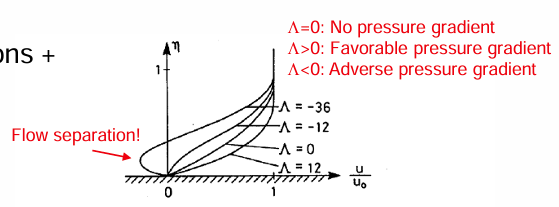

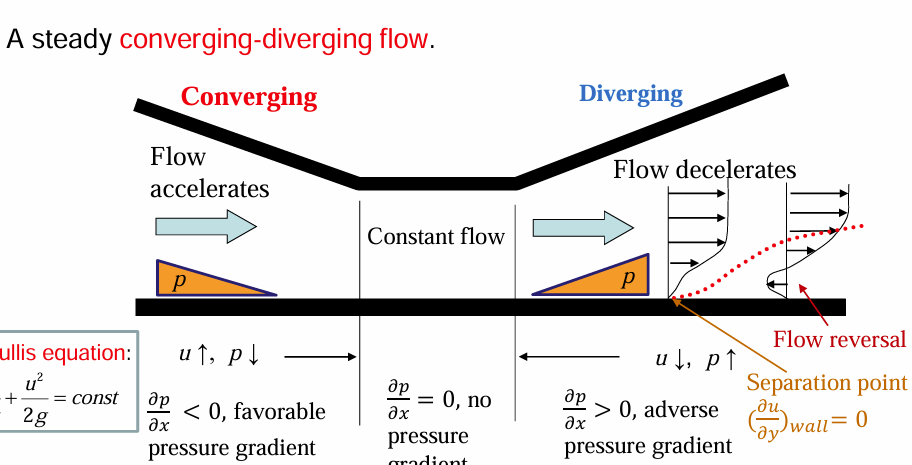

### Code for Numeric Results

In [ ]:
import sympy as sp, numpy as np

# parameters
nu = 1e-6           # kinematic viscosity (m^2/s)
t = 10.0            # time (s)
U = 1.0             # free stream velocity (m/s)
rho = 1000.0        # density (kg/m^3)
mu = rho*nu         # dynamic viscosity (Pa.s)

eta = sp.Symbol('eta', real=True)
# profiles
f1 = 1 - eta
f2 = (1 - eta)**2
f3 = 1 - sp.sin(sp.pi/2*eta)
dfs = [sp.diff(f,eta) for f in (f1,f2,f3)]

# compute hat-delta, integrals etc.
hat_deltas = []
int_fs = []
for f, df in zip((f1,f2,f3), dfs):
    I = sp.integrate(eta*df, (eta,0,1))             # Eq. 5.48 (denominator)
    hat = sp.sqrt(2*df.subs(eta,0)/I)               # Eq. 5.48 (numerator)
    hat_deltas.append(float(hat))                   # Store them to then multiply by sqrt(nu*t)
    int_fs.append(float(sp.integrate(f,(eta,0,1)))) # Eq. 5.49 (without multiplication by delta)

sqrt_nut = np.sqrt(nu*t)
deltas = [h*sqrt_nut for h in hat_deltas]
dstars = [d*I for d,I in zip(deltas,int_fs)]
fprime0 = [float(df.subs(eta,0)) for df in dfs]
taus = [mu*U/d * fp0 for d,fp0 in zip(deltas,fprime0)]

print("hat_deltas:", hat_deltas) # The dimensionless boundary layer thicknesses (calculated in first part)
print("deltas (m):", deltas)
print("delta* (m):", dstars)
print("tau_w (Pa):", taus)


hat_deltas: [2.0, 3.4641016151377544, 2.940317915014975]
deltas (m): [0.006324555320336759, 0.010954451150103323, 0.009298101656444723]
delta* (m): [0.0031622776601683794, 0.0036514837167011074, 0.0033787462964682525]
tau_w (Pa): [-0.15811388300841897, -0.18257418583505536, -0.16893731482341262]


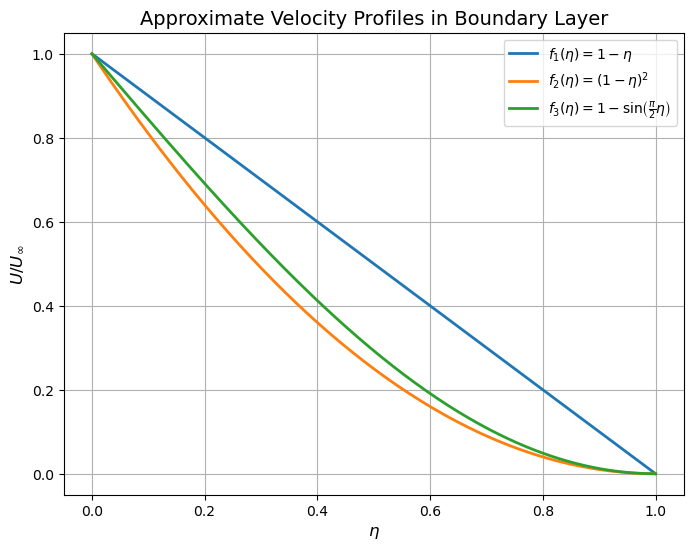

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Define eta from 0 to 1
eta_vals = np.linspace(0, 1, 200)

# Velocity profiles
f1_vals = 1 - eta_vals
f2_vals = (1 - eta_vals)**2
f3_vals = 1 - np.sin((np.pi/2) * eta_vals)

# Plot
plt.figure(figsize=(8,6))
plt.plot(eta_vals, f1_vals, label=r'$f_1(\eta) = 1 - \eta$', linewidth=2)
plt.plot(eta_vals, f2_vals, label=r'$f_2(\eta) = (1 - \eta)^2$', linewidth=2)
plt.plot(eta_vals, f3_vals, 
         label=r'$f_3(\eta) = 1 - \sin\!\left(\frac{\pi}{2}\eta\right)$', 
         linewidth=2)


plt.xlabel(r'$\eta$', fontsize=12)
plt.ylabel(r'$U/U_\infty$', fontsize=12)
plt.title('Approximate Velocity Profiles in Boundary Layer', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
